# 🧠 Mental Health Trend Monitor — Notebook 01 : Analyse Exploratoire Initiale

**Projet :** Mental Health Trend Monitor  
**Phase :** Phase 1 — Cadrage et constitution du dataset  
**Auteur :** P3 — Notebook Engineer  
**Date :** 2025-2026  

---

## Objectif de ce notebook

Ce notebook réalise l'analyse exploratoire initiale (*discovery*) du dataset Reddit collecté par P1.  
Il couvre :
- Le chargement et l'inspection structurelle du dataset (`df.info()`, `df.describe()`, `df.head()`)
- L'analyse des valeurs manquantes
- La vérification du déséquilibre de la variable cible `is_distress`
- La distribution des features numériques et catégorielles
- L'identification des problèmes à traiter en Phase 2

---

## 0. Imports et configuration

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Style global des graphiques
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

print("✅ Imports OK")

✅ Imports OK


---
## 1. Chargement du dataset

In [11]:
# Chargement du dataset complet
df = pd.read_csv('../data/dataset.csv')

print(f"📦 Dataset chargé avec succès.")
print(f"   ▸ Lignes    : {df.shape[0]:,}")
print(f"   ▸ Colonnes  : {df.shape[1]}")

📦 Dataset chargé avec succès.
   ▸ Lignes    : 800
   ▸ Colonnes  : 12


In [12]:
# Aperçu des premières lignes
df.head(10)

,hour_of_day,title_length_chars,body_length_chars,title_ends_with_question,is_nsfw,has_url_in_body,author_is_new,author_comment_karma,author_post_karma,flair_text,subreddit,is_distress
0,14,28,0,0,0,0,-1,-1,-1,NaN,fitness,0
1,18,59,0,0,0,0,-1,-1,-1,NaN,fitness,0
2,18,50,738,0,0,0,-1,-1,-1,NaN,depression,1
3,21,66,0,1,0,0,-1,-1,-1,NaN,AskReddit,0
4,18,62,2949,0,0,0,-1,-1,-1,NaN,depression,1
5,14,52,0,0,0,0,-1,-1,-1,NaN,fitness,0
6,20,25,0,0,0,0,-1,-1,-1,Content Warning: Suicidal Thoughts / Self Harm,mentalhealth,1
7,13,41,151,0,0,0,-1,-1,-1,NaN,CasualConversation,0
8,22,44,154,0,0,0,-1,-1,-1,Technique,productivity,0
9,16,37,655,0,0,0,-1,-1,-1,NaN,CasualConversation,0


---
## 2. Inspection structurelle

In [13]:
# Types de données et valeurs non-nulles
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   hour_of_day               800 non-null    int64
 1   title_length_chars        800 non-null    int64
 2   body_length_chars         800 non-null    int64
 3   title_ends_with_question  800 non-null    int64
 4   is_nsfw                   800 non-null    int64
 5   has_url_in_body           800 non-null    int64
 6   author_is_new             800 non-null    int64
 7   author_comment_karma      800 non-null    int64
 8   author_post_karma         800 non-null    int64
 9   flair_text                350 non-null    str  
 10  subreddit                 800 non-null    str  
 11  is_distress               800 non-null    int64
dtypes: int64(10), str(2)
memory usage: 75.1 KB


In [14]:
# Statistiques descriptives — variables numériques
df.describe().round(2)

,hour_of_day,title_length_chars,body_length_chars,title_ends_with_question,is_nsfw,has_url_in_body,author_is_new,author_comment_karma,author_post_karma,is_distress
count,800.00,800.00,800.00,800.00,800.00,800.00,800.0,800.0,800.0,800.0
mean,17.32,51.07,497.99,0.35,0.06,0.00,-1.0,-1.0,-1.0,0.5
std,4.07,34.44,827.12,0.48,0.23,0.06,0.0,0.0,0.0,0.5
min,0.00,1.00,0.00,0.00,0.00,0.00,-1.0,-1.0,-1.0,0.0
25%,16.00,26.00,0.00,0.00,0.00,0.00,-1.0,-1.0,-1.0,0.0
50%,18.00,44.00,31.00,0.00,0.00,0.00,-1.0,-1.0,-1.0,0.5
75%,20.00,66.00,688.00,1.00,0.00,0.00,-1.0,-1.0,-1.0,1.0
max,23.00,299.00,8917.00,1.00,1.00,1.00,-1.0,-1.0,-1.0,1.0


In [15]:
# Statistiques descriptives — variables catégorielles
df.describe(include='object')

,flair_text,subreddit
count,350,800
unique,35,8
top,Question,fitness
freq,59,100


### 📋 Schéma des colonnes

| Colonne | Type | Description |
|---|---|---|
| `hour_of_day` | Numérique (int) | Heure de publication du post (0–23) |
| `title_length_chars` | Numérique (int) | Longueur du titre en caractères |
| `body_length_chars` | Numérique (int) | Longueur du corps du post en caractères |
| `title_ends_with_question` | Binaire (0/1) | Le titre se termine-t-il par '?' |
| `is_nsfw` | Binaire (0/1) | Le post est-il marqué NSFW |
| `has_url_in_body` | Binaire (0/1) | Le corps contient-il une URL |
| `author_is_new` | Binaire / -1 | Le compte auteur est-il récent |
| `author_comment_karma` | Numérique / -1 | Karma commentaires de l'auteur |
| `author_post_karma` | Numérique / -1 | Karma posts de l'auteur |
| `flair_text` | Catégorielle | Étiquette de flair associée au post |
| `subreddit` | Catégorielle | Subreddit source du post |
| `is_distress` | **Cible** (0/1) | **0** = non-détresse · **1** = détresse |


---
## 3. Analyse des valeurs manquantes

In [16]:
# Tableau des valeurs manquantes
missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Valeurs manquantes' : missing_count,
    'Pourcentage (%)'    : missing_pct
}).sort_values('Valeurs manquantes', ascending=False)

print(missing_df.to_string())

                          Valeurs manquantes  Pourcentage (%)
flair_text                               450            56.25
hour_of_day                                0             0.00
body_length_chars                          0             0.00
title_length_chars                         0             0.00
title_ends_with_question                   0             0.00
is_nsfw                                    0             0.00
author_is_new                              0             0.00
has_url_in_body                            0             0.00
author_comment_karma                       0             0.00
author_post_karma                          0             0.00
subreddit                                  0             0.00
is_distress                                0             0.00


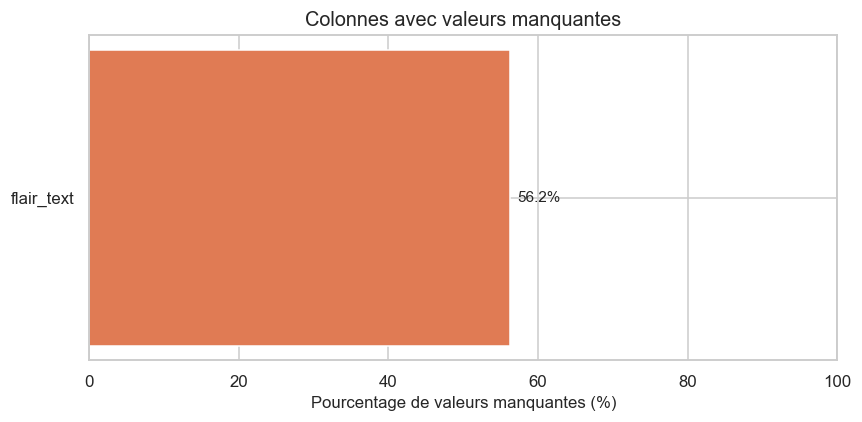

In [17]:
# Visualisation des valeurs manquantes
cols_with_missing = missing_df[missing_df['Valeurs manquantes'] > 0]

if len(cols_with_missing) > 0:
    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.barh(
        cols_with_missing.index,
        cols_with_missing['Pourcentage (%)'],
        color='#e07b54', edgecolor='white'
    )
    ax.set_xlabel('Pourcentage de valeurs manquantes (%)')
    ax.set_title('Colonnes avec valeurs manquantes')
    ax.set_xlim(0, 100)
    for bar, pct in zip(bars, cols_with_missing['Pourcentage (%)']):
        ax.text(pct + 1, bar.get_y() + bar.get_height()/2,
                f'{pct:.1f}%', va='center', fontsize=10)
    plt.tight_layout()
    plt.savefig('../figures/missing_values.png', bbox_inches='tight')
    plt.show()
else:
    print('Aucune valeur manquante détectée.')

> **⚠️ Observation :** La colonne `flair_text` présente **56.25 % de valeurs manquantes** (450/800 posts).  
> Cette colonne reste potentiellement utile pour les posts qui en disposent, mais nécessitera une stratégie d'imputation en Phase 2 (ex : remplacement par `"No Flair"`).

---
## 4. Colonnes inutilisables — valeurs constantes à -1

In [18]:
# Vérification des colonnes auteur
author_cols = ['author_is_new', 'author_comment_karma', 'author_post_karma']

print("Valeurs uniques par colonne auteur :")
for col in author_cols:
    unique_vals = df[col].unique()
    pct_minus1  = (df[col] == -1).mean() * 100
    print(f"  {col:30s} → valeurs : {unique_vals}  |  -1 : {pct_minus1:.1f}%")

Valeurs uniques par colonne auteur :
  author_is_new                  → valeurs : [-1]  |  -1 : 100.0%
  author_comment_karma           → valeurs : [-1]  |  -1 : 100.0%
  author_post_karma              → valeurs : [-1]  |  -1 : 100.0%


> **⚠️ Observation critique :** Les trois colonnes `author_is_new`, `author_comment_karma` et `author_post_karma` contiennent **100 % de valeurs égales à -1**.  
> La collecte PRAW n'a pas réussi à récupérer ces informations (probablement un problème de permissions ou de comptes supprimés).  
> **Ces colonnes seront supprimées en Phase 2** — elles n'apportent aucune information discriminante.

---
## 5. Distribution de la variable cible `is_distress`

In [19]:
# Comptage brut et proportions
counts = df['is_distress'].value_counts()
props  = df['is_distress'].value_counts(normalize=True).mul(100).round(2)

distress_summary = pd.DataFrame({
    'Classe'     : ['Non-détresse (0)', 'Détresse (1)'],
    'Effectif'   : [counts[0], counts[1]],
    'Proportion' : [f"{props[0]:.2f} %", f"{props[1]:.2f} %"]
})
print(distress_summary.to_string(index=False))

          Classe  Effectif Proportion
Non-détresse (0)       400    50.00 %
    Détresse (1)       400    50.00 %


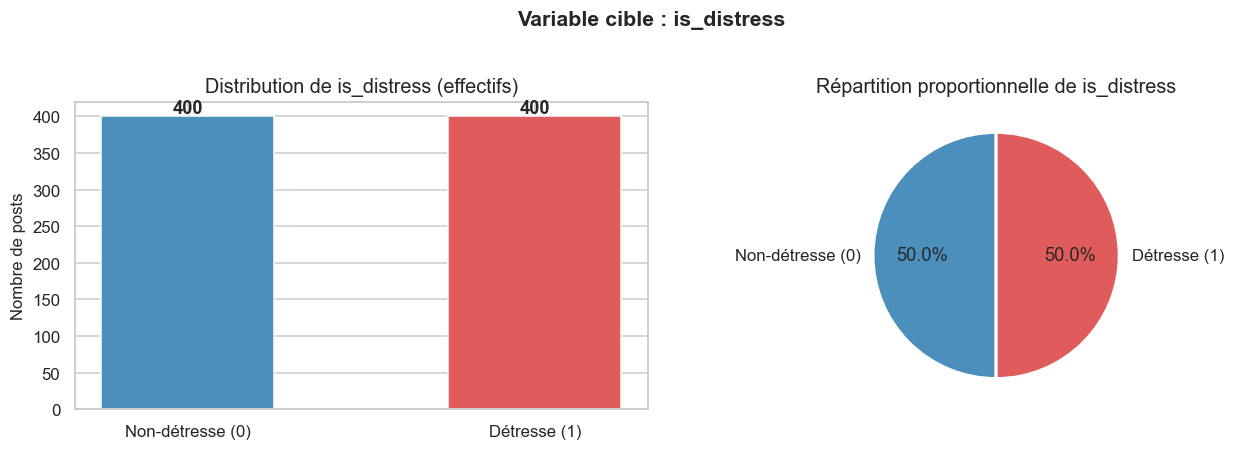

In [20]:
# Visualisation de la distribution de la cible
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Barplot ---
colors = ['#4c8fbd', '#e05c5c']
axes[0].bar(
    ['Non-détresse (0)', 'Détresse (1)'],
    [counts[0], counts[1]],
    color=colors, edgecolor='white', width=0.5
)
axes[0].set_title('Distribution de is_distress (effectifs)')
axes[0].set_ylabel('Nombre de posts')
for i, v in enumerate([counts[0], counts[1]]):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# --- Pie chart ---
axes[1].pie(
    [counts[0], counts[1]],
    labels=['Non-détresse (0)', 'Détresse (1)'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Répartition proportionnelle de is_distress')

plt.suptitle('Variable cible : is_distress', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/class_distribution.png', bbox_inches='tight')
plt.show()

> **🚨 Problème critique — Contrainte du projet NON respectée :**  
> Le dataset présente un équilibre parfait de **50 % / 50 %** entre les deux classes.  
> Le cahier des charges impose une **classe minoritaire entre 5 % et 25 %**.  
> 
> **Action requise de P1 :** Revoir la stratégie de collecte pour obtenir un déséquilibre conforme.  
> Options possibles :
> - Collecter davantage de posts non-distress pour diluer la classe positive
> - Utiliser un sous-échantillonnage ciblé de la classe `is_distress = 1`
> - Élargir les subreddits non-distress (ex : r/cooking, r/photography, r/gaming)

---
## 6. Distribution de `is_distress` par subreddit

In [21]:
# Tableau croisé subreddit × is_distress
cross = df.groupby('subreddit')['is_distress'].value_counts().unstack(fill_value=0)
cross.columns = ['Non-détresse (0)', 'Détresse (1)']
cross['Total'] = cross.sum(axis=1)
cross['% Détresse'] = (cross['Détresse (1)'] / cross['Total'] * 100).round(1)
print(cross.to_string())

                    Non-détresse (0)  Détresse (1)  Total  % Détresse
subreddit                                                            
AskReddit                        100             0    100         0.0
CasualConversation               100             0    100         0.0
SuicideWatch                       0           100    100       100.0
anxiety                            0           100    100       100.0
depression                         0           100    100       100.0
fitness                          100             0    100         0.0
mentalhealth                       0           100    100       100.0
productivity                     100             0    100         0.0


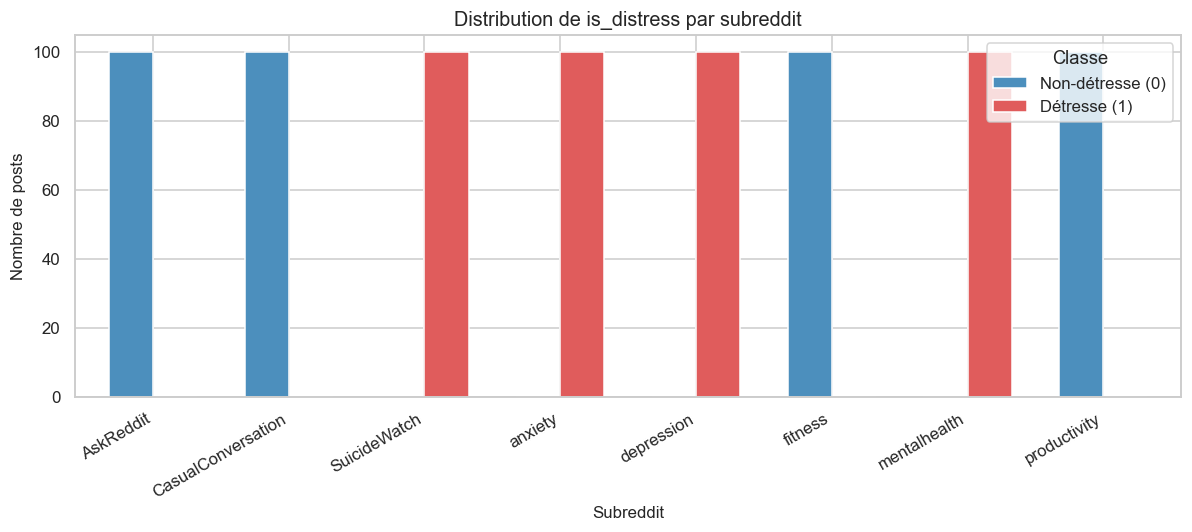

In [22]:
# Visualisation : distribution is_distress par subreddit
cross_plot = df.groupby(['subreddit', 'is_distress']).size().unstack(fill_value=0)
cross_plot.columns = ['Non-détresse (0)', 'Détresse (1)']

fig, ax = plt.subplots(figsize=(11, 5))
cross_plot.plot(
    kind='bar', ax=ax,
    color=['#4c8fbd', '#e05c5c'],
    edgecolor='white', width=0.65
)
ax.set_title('Distribution de is_distress par subreddit')
ax.set_xlabel('Subreddit')
ax.set_ylabel('Nombre de posts')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(title='Classe')
plt.tight_layout()
plt.savefig('../figures/distress_by_subreddit.png', bbox_inches='tight')
plt.show()

> **⚠️ Observation — Fuite de données potentielle (Data Leakage) :**  
> La variable `subreddit` est **parfaitement corrélée** à la variable cible `is_distress` :
> 
> | Subreddit | is_distress |
> |---|---|
> | `SuicideWatch`, `anxiety`, `depression`, `mentalhealth` | **100 % Détresse (1)** |
> | `fitness`, `productivity`, `AskReddit`, `CasualConversation` | **100 % Non-détresse (0)** |
> 
> Si on laisse `subreddit` comme feature d'entrée du modèle, le classifieur pourra **prédire parfaitement sans rien apprendre** sur le contenu réel des posts.  
> **Action recommandée en Phase 2 :** Supprimer ou encoder prudemment la colonne `subreddit`.

---
## 7. Distribution des features numériques

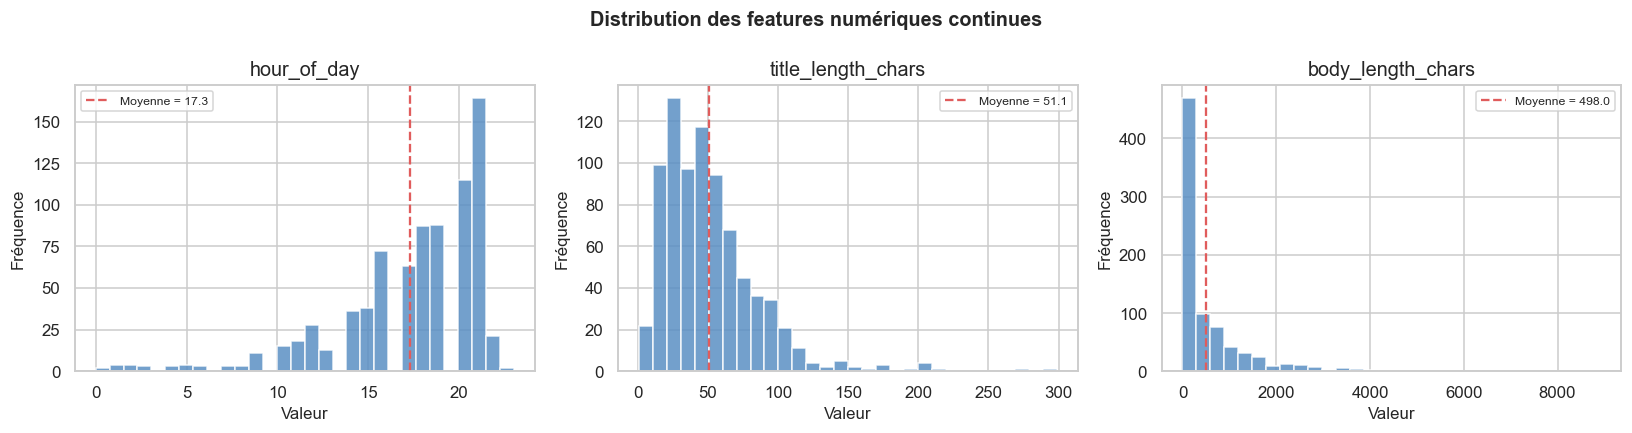

In [23]:
# Histogrammes des features numériques continues
num_cols = ['hour_of_day', 'title_length_chars', 'body_length_chars']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, num_cols):
    ax.hist(df[col], bins=30, color='#5a8fc4', edgecolor='white', alpha=0.85)
    ax.set_title(col)
    ax.set_xlabel('Valeur')
    ax.set_ylabel('Fréquence')
    mean_val = df[col].mean()
    ax.axvline(mean_val, color='#e05c5c', linestyle='--', linewidth=1.5,
               label=f'Moyenne = {mean_val:.1f}')
    ax.legend(fontsize=8)

plt.suptitle('Distribution des features numériques continues', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/numeric_distributions.png', bbox_inches='tight')
plt.show()

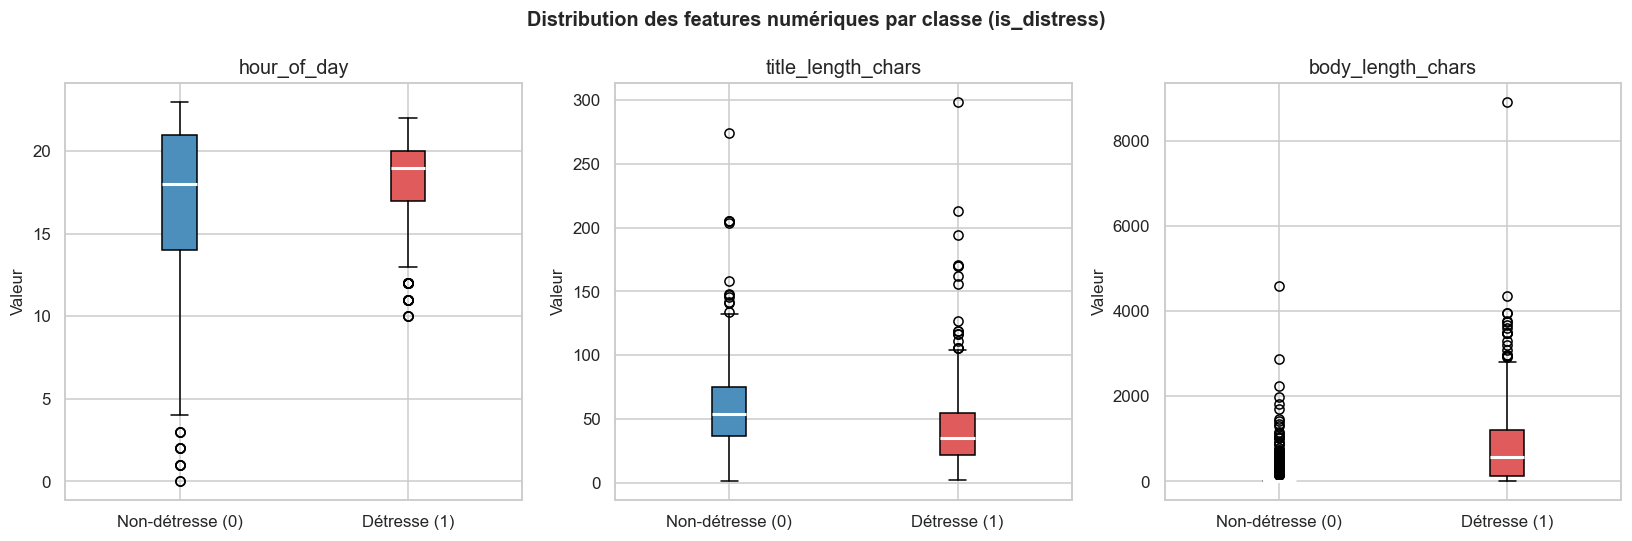

In [24]:
# Boxplot : features numériques selon la classe cible
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, num_cols):
    data_0 = df[df['is_distress'] == 0][col]
    data_1 = df[df['is_distress'] == 1][col]
    bp = ax.boxplot(
        [data_0, data_1],
        labels=['Non-détresse (0)', 'Détresse (1)'],
        patch_artist=True,
        medianprops={'color': 'white', 'linewidth': 2}
    )
    bp['boxes'][0].set_facecolor('#4c8fbd')
    bp['boxes'][1].set_facecolor('#e05c5c')
    ax.set_title(col)
    ax.set_ylabel('Valeur')

plt.suptitle('Distribution des features numériques par classe (is_distress)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/boxplot_by_class.png', bbox_inches='tight')
plt.show()

> **📊 Observations :**
> - **`body_length_chars`** : les posts de détresse sont significativement **plus longs** (moyenne ≈ 852 chars) que les posts non-distress (moyenne ≈ 144 chars). C'est un signal discriminant fort.
> - **`hour_of_day`** : la distribution est centrée sur 16h–20h dans les deux classes, peu de différence notable.
> - **`title_length_chars`** : distributions similaires dans les deux classes.

---
## 8. Analyse des features binaires

In [25]:
# Taux de chaque feature binaire par classe
binary_cols = ['title_ends_with_question', 'is_nsfw', 'has_url_in_body']

binary_stats = df.groupby('is_distress')[binary_cols].mean().mul(100).round(2)
binary_stats.index = ['Non-détresse (0)', 'Détresse (1)']
binary_stats.columns = [
    'Titre = question (%)',
    'NSFW (%)',
    'URL dans le corps (%)'
]
print(binary_stats.to_string())

                  Titre = question (%)  NSFW (%)  URL dans le corps (%)
Non-détresse (0)                 49.00      1.75                   0.75
Détresse (1)                     21.25      9.50                   0.00


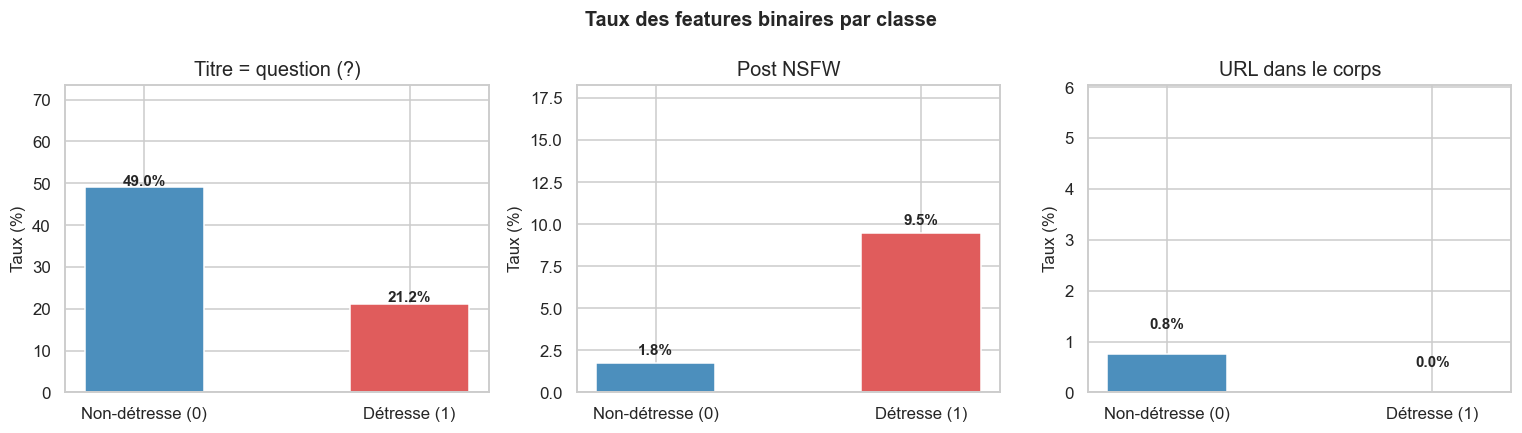

In [26]:
# Visualisation : taux des features binaires par classe
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
labels    = ['Non-détresse (0)', 'Détresse (1)']
colors    = ['#4c8fbd', '#e05c5c']
titles    = ['Titre = question (?)', 'Post NSFW', 'URL dans le corps']

for ax, col, title in zip(axes, binary_cols, titles):
    rates = df.groupby('is_distress')[col].mean().mul(100)
    ax.bar(labels, rates.values, color=colors, edgecolor='white', width=0.45)
    ax.set_title(title)
    ax.set_ylabel('Taux (%)')
    ax.set_ylim(0, max(rates.values) * 1.4 + 5)
    for i, v in enumerate(rates.values):
        ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Taux des features binaires par classe', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/binary_features_by_class.png', bbox_inches='tight')
plt.show()

> **📊 Observations :**
> - **`title_ends_with_question`** : les posts non-distress posent plus souvent des questions (49 %) que les posts de détresse (21.3 %). Signal pertinent.
> - **`is_nsfw`** : les posts de détresse sont plus fréquemment NSFW (9.5 % vs 1.75 %). Cohérent avec des contenus de contenu sensible.
> - **`has_url_in_body`** : très rare dans les deux classes (< 1 %). Peu de valeur prédictive.

---
## 9. Analyse de `flair_text`

In [27]:
# Distribution des flairs (posts avec flair seulement)
flair_counts = df['flair_text'].value_counts(dropna=True).head(12)
print(f"Nombre de valeurs uniques dans flair_text : {df['flair_text'].nunique()}")
print(f"Posts avec flair : {df['flair_text'].notna().sum()} / {len(df)} ({df['flair_text'].notna().mean()*100:.1f}%)")
print()
print("Top 12 flairs :")
print(flair_counts.to_string())

Nombre de valeurs uniques dans flair_text : 35
Posts avec flair : 350 / 800 (43.8%)

Top 12 flairs :
flair_text
Question                                          59
Advice Needed                                     43
Venting                                           29
Content Warning: Suicidal Thoughts / Self Harm    26
:chat: Just Chatting                              22
Medication                                        20
Health                                            18
General Advice                                    18
Technique                                         14
Need Support                                      14
Opinion / Thoughts                                11
Software                                           9


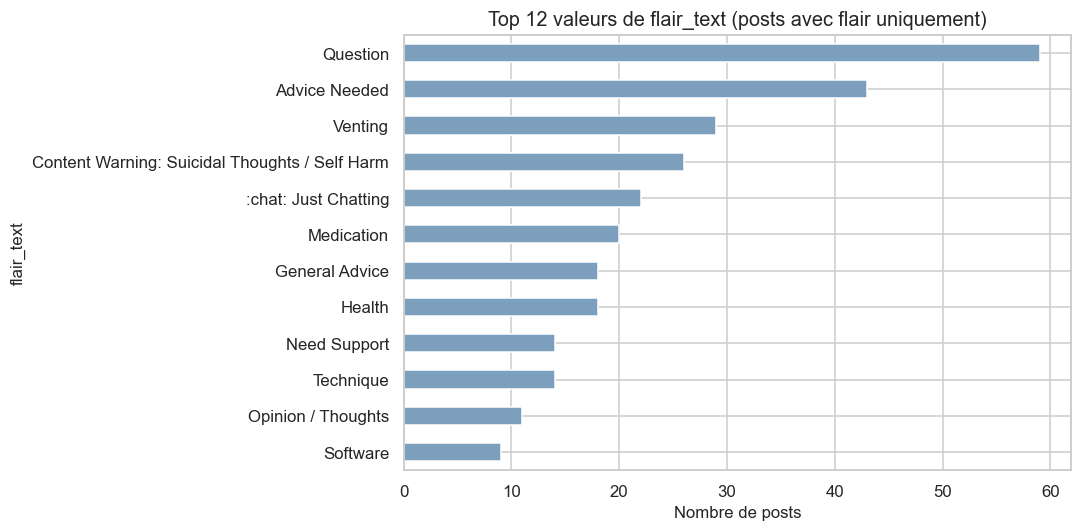

In [28]:
# Graphique : top 12 flairs
fig, ax = plt.subplots(figsize=(10, 5))
flair_counts.sort_values().plot(
    kind='barh', ax=ax,
    color='#7b9fbd', edgecolor='white'
)
ax.set_title('Top 12 valeurs de flair_text (posts avec flair uniquement)')
ax.set_xlabel('Nombre de posts')
plt.tight_layout()
plt.savefig('../figures/flair_distribution.png', bbox_inches='tight')
plt.show()

> **📊 Observations :**
> - `flair_text` contient **56.25 % de valeurs manquantes** → imputation requise en Phase 2 (valeur de remplacement : `"No Flair"`).
> - Les flairs présents sont très informatifs : *"Content Warning: Suicidal Thoughts"*, *"Venting"*, *"Need Support"* → forte valeur prédictive pour la classe de détresse.
> - Il faudra regrouper les flairs rares (< 5 occurrences) en une catégorie `"Other"` pour éviter le bruit.

---
## 10. Matrice de corrélation — features numériques

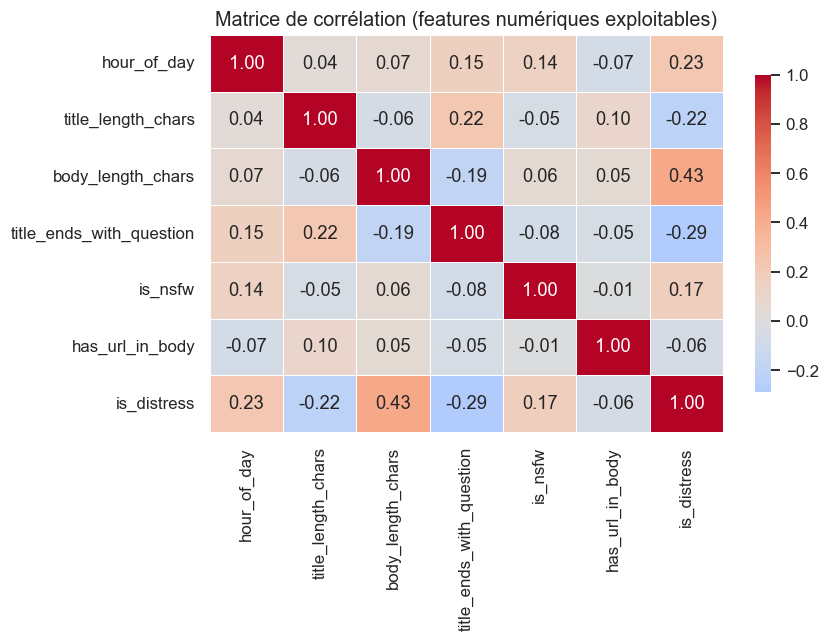

In [29]:
# Sélection des colonnes numériques exploitables (hors colonnes constantes à -1)
usable_num_cols = [
    'hour_of_day', 'title_length_chars', 'body_length_chars',
    'title_ends_with_question', 'is_nsfw', 'has_url_in_body', 'is_distress'
]

corr_matrix = df[usable_num_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5, linecolor='white',
    ax=ax, cbar_kws={'shrink': 0.8}
)
ax.set_title('Matrice de corrélation (features numériques exploitables)')
plt.tight_layout()
plt.savefig('../figures/correlation_matrix.png', bbox_inches='tight')
plt.show()

> **📊 Observations :**
> - **`body_length_chars`** est la feature la plus corrélée à `is_distress` parmi les features numériques disponibles.
> - **`is_nsfw`** présente également une corrélation positive avec `is_distress`.
> - **`title_ends_with_question`** est négativement corrélé à `is_distress` (les questions sont moins fréquentes dans les posts de détresse).
> - Peu de multicolinéarité entre les features — bon signe pour les modèles linéaires.

---
## 11. Résumé des problèmes identifiés et recommandations

In [30]:
# Tableau récapitulatif des problèmes
problems = {
    'Problème': [
        'Déséquilibre 50/50 (contrainte non respectée)',
        'Colonnes author_* toujours à -1',
        'flair_text : 56.25% manquant',
        'subreddit corrélé à 100% avec is_distress',
        'has_url_in_body : 0.4% seulement',
        'Taille : 800 lignes (< 10 000 requis)',
    ],
    'Sévérité': ['🚨 Critique', '🚨 Critique', '⚠️ Modéré', '🚨 Critique', '⚠️ Modéré', '🚨 Critique'],
    'Action recommandée': [
        'P1 : recollecte ciblée pour atteindre 5-25% de classe minoritaire',
        'Supprimer ces 3 colonnes en Phase 2',
        'Imputer avec "No Flair" en Phase 2',
        'Supprimer ou encoder avec précaution en Phase 2',
        'Supprimer en Phase 2 (variance nulle ou quasi-nulle)',
        'P1 : compléter la collecte jusqu\'à ≥ 10 000 lignes',
    ]
}

problems_df = pd.DataFrame(problems)
print(problems_df.to_string(index=False))

                                     Problème   Sévérité                                                Action recommandée
Déséquilibre 50/50 (contrainte non respectée) 🚨 Critique P1 : recollecte ciblée pour atteindre 5-25% de classe minoritaire
              Colonnes author_* toujours à -1 🚨 Critique                               Supprimer ces 3 colonnes en Phase 2
                 flair_text : 56.25% manquant  ⚠️ Modéré                                Imputer avec "No Flair" en Phase 2
    subreddit corrélé à 100% avec is_distress 🚨 Critique                   Supprimer ou encoder avec précaution en Phase 2
             has_url_in_body : 0.4% seulement  ⚠️ Modéré              Supprimer en Phase 2 (variance nulle ou quasi-nulle)
        Taille : 800 lignes (< 10 000 requis) 🚨 Critique                P1 : compléter la collecte jusqu'à ≥ 10 000 lignes


---

## ✅ Conclusion

### Ce que ce notebook confirme

Le dataset collecté est **structurellement exploitable** pour une analyse exploratoire initiale : les colonnes sont bien typées, les features numériques présentent des distributions variées et plusieurs d'entre elles montrent déjà des différences notables entre les classes.

### Problèmes critiques à résoudre avant la Phase 2

| # | Problème | Responsable |
|---|---|---|
| 1 | **Dataset trop petit (800 lignes, besoin ≥ 10 000)** | P1 — Data Engineer |
| 2 | **Déséquilibre parfait 50/50 (besoin 5–25 % minoritaire)** | P1 — Data Engineer |
| 3 | **Colonnes `author_*` inutilisables (100 % de -1)** | P1 + P2 |
| 4 | **`subreddit` = fuite de données directe vers la cible** | P2 + Équipe |

### Features les plus prometteuses pour la Phase 2

| Feature | Pourquoi |
|---|---|
| `body_length_chars` | Fort signal : les posts de détresse sont 6× plus longs |
| `flair_text` | Très informatif quand disponible (*Venting*, *Need Support*, etc.) |
| `is_nsfw` | Corrélé à la détresse (9.5 % vs 1.75 %) |
| `title_ends_with_question` | Signal négatif : la détresse pose moins de questions |

---

*Notebook réalisé dans le cadre du Projet de Fin de Module Machine Learning — Phase 1*  
*GI2 · 2025–2026 · Pr. Y. EL YOUNOUSSI*